# Ring galaxy formation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sgpfaff/tambora-docs/blob/master/docs/examples/08-ring-galaxy.ipynb)

Drop a compact companion straight through the middle of a disk galaxy and the
disk does not simply scatter. The stars are pulled inward together, over-shoot,
and rebound as a coherent density wave that travels outward — a ring. The
Cartwheel galaxy is the textbook case, and Lynds & Toomre (1976) is the paper
that explained it.

The mechanism is worth stating up front, because it is not what most people
guess. The ring is **not** a shell of swept-up material being pushed outward by
the intruder. Nothing is being pushed. The intruder's passage is nearly
impulsive, so every star gets an inward velocity kick and then keeps orbiting
in the *unchanged* background potential. Stars at different radii have
different epicyclic frequencies, so their orbits crowd together at a radius
that grows with time. The ring is a **kinematic caustic** — a traffic jam in
orbit phase, not a wall of matter.

This notebook builds an exponential disk from scratch, fires an intruder
through it, and then checks that reading of the physics quantitatively.

**Runtime.** About 6 minutes at the default resolution, under a minute with
`QUICK = True`.

## Setup

On Colab, run the install cell. Locally, skip it if you already have tambora
and galpy.

In [1]:
# Colab / fresh environment only:
%pip install --pre --quiet "tambora==0.1.0a1" galpy astropy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from galpy import potential
from galpy.potential import DoubleExponentialDiskPotential, NFWPotential

import tambora
from tambora.simulation import Sim
from tambora.tools import mkPlummer_galpy
from tambora.tools.util.units import G_KPC_KMS, KPCGYR_TO_KMS

print("tambora", tambora.__version__)

# House style for every figure in these docs.
try:
    plt.style.use("../_static/tambora.mplstyle")
except OSError:
    pass

rng = np.random.default_rng(23)
np.random.seed(23)

QUICK = False  # True -> 6000 disk particles, coarser output

tambora 0.1.0a1


## 1. A disk, built by hand

Every sampler that ships with tambora is spherical — `mkPlummer_galpy`,
`mkKing_galpy`, `mkNFW_galpy` and the `galpysampler` Eddington inversion all
assume $\rho(r)$. A disk is not spherical, so this is the point where you roll
your own, exactly as in
[example 02](02-initial-conditions.ipynb). All `add_particles` ever wants is
three arrays in kpc, km/s and M☉.

We sample the standard double-exponential,

$$ \rho(R, z) \;\propto\; e^{-R/h_R}\, e^{-|z|/h_z}, $$

which has the convenient property that galpy has the *exact* potential for it
(`DoubleExponentialDiskPotential`). So the density we sample and the rotation
curve we impose come from the same model, rather than the usual fudge of
sampling an exponential and then using a Miyamoto–Nagai rotation curve.

In [3]:
M_DISK = 5.0e10  # disk mass [Msun]
H_R = 3.5  # radial scale length [kpc]
H_Z = 0.30  # vertical scale height [kpc]
R_MAX = 5.0 * H_R  # truncate the sampled disk here [kpc]

M_HALO = 3.0e11  # NFW halo mass [Msun]
A_HALO = 16.0  # NFW scale radius [kpc]

# rho_0 for the double exponential: M = rho_0 * (2 pi h_R^2) * (2 h_z).
rho0 = M_DISK / (4.0 * np.pi * H_R**2 * H_Z)

disk_pot = DoubleExponentialDiskPotential(
    amp=rho0 * u.Msun / u.kpc**3, hr=H_R * u.kpc, hz=H_Z * u.kpc, ro=8.0, vo=220.0
)
halo_pot = NFWPotential(amp=M_HALO * u.Msun, a=A_HALO * u.kpc, ro=8.0, vo=220.0)
for _p in (disk_pot, halo_pot):
    _p.turn_physical_on()  # so vcirc() comes back as a Quantity
model = [disk_pot, halo_pot]

print(f"disk   M = {M_DISK:.2e} Msun, h_R = {H_R} kpc, h_z = {H_Z} kpc")
print(f"halo   M = {M_HALO:.2e} Msun, a = {A_HALO} kpc")

/private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora-docs/67f2c9a1-fd52-4fb9-a988-3ccca0e9a3dc/scratchpad/tamboraenv/lib/python3.13/site-packages/galpy/potential/DoubleExponentialDiskPotential.py:19: RuntimeWarning: overflow encountered in sinh
  return (numpy.sinh(numpy.pi * numpy.sinh(t)) + numpy.pi * t * numpy.cosh(t)) / (

/private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora-docs/67f2c9a1-fd52-4fb9-a988-3ccca0e9a3dc/scratchpad/tamboraenv/lib/python3.13/site-packages/galpy/potential/DoubleExponentialDiskPotential.py:20: RuntimeWarning: overflow encountered in cosh
  numpy.cosh(numpy.pi * numpy.sinh(t)) + 1

/private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora-docs/67f2c9a1-fd52-4fb9-a988-3ccca0e9a3dc/scratchpad/tamboraenv/lib/python3.13/site-packages/galpy/potential/DoubleExponentialDiskPotential.py:19: RuntimeWarning: invalid value encountered in divide
  return (numpy.sinh(numpy.pi * numpy.sinh(t)) + numpy.pi * t * numpy.cosh(t)) / (

disk   M = 5.00e+10 Ms

### The rotation curve, and the frequencies that follow from it

`DoubleExponentialDiskPotential` evaluates by numerical quadrature, so it is
far too slow to call once per particle. Build it once on a grid and interpolate
— a pattern worth remembering for any expensive potential.

The epicyclic frequency comes from the same grid by finite difference,

$$ \kappa^2 = R\,\frac{d\Omega^2}{dR} + 4\Omega^2, $$

rather than from `galpy.potential.epifreq`, so you can see exactly where it
comes from.

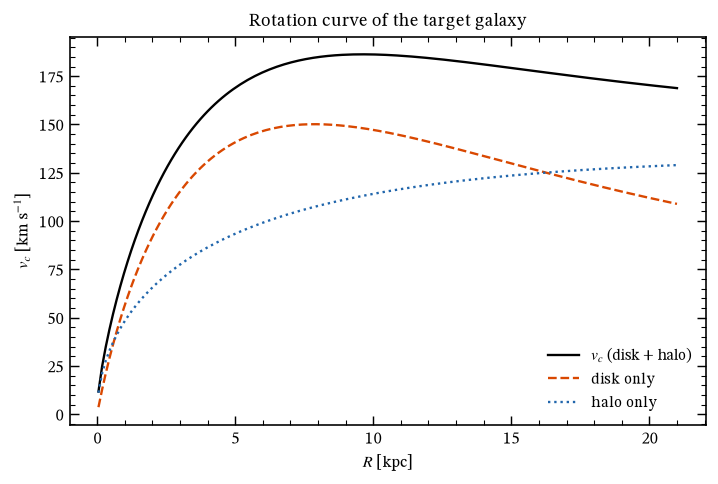

In [4]:
# galpy's DoubleExponentialDiskPotential integrates by tanh-sinh quadrature and
# harmlessly overflows in the tails of the transform; the result is fine. Passing
# ro/vo explicitly makes vcirc return km/s as a plain float for a potential list.
def vc_of(pot, R):
    """Circular speed [km/s] at radii R [kpc], quietly."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        return np.array(
            [float(potential.vcirc(pot, float(r) * u.kpc, ro=8.0, vo=220.0)) for r in np.atleast_1d(R)]
        )


R_grid = np.linspace(0.05, R_MAX * 1.2, 160)
vc_grid = vc_of(model, R_grid)

Omega_grid = vc_grid / R_grid  # km/s/kpc
kappa2_grid = R_grid * np.gradient(Omega_grid**2, R_grid) + 4.0 * Omega_grid**2
kappa_grid = np.sqrt(np.clip(kappa2_grid, 1e-12, None))


def vcirc(R):
    return np.interp(R, R_grid, vc_grid)


def Omega(R):
    return np.interp(R, R_grid, Omega_grid)


def kappa(R):
    return np.interp(R, R_grid, kappa_grid)


fig, ax = plt.subplots(figsize=(5.6, 3.8))
ax.plot(R_grid, vc_grid, "k", label=r"$v_c$ (disk + halo)")
ax.plot(
    R_grid,
    vc_of(disk_pot, R_grid),
    c="#d94801", ls="--", label="disk only",
)
ax.plot(
    R_grid,
    vc_of(halo_pot, R_grid),
    c="#2166ac", ls=":", label="halo only",
)
ax.set_xlabel("$R$ [kpc]")
ax.set_ylabel("$v_c$ [km s$^{-1}$]")
ax.set_title("Rotation curve of the target galaxy")
ax.legend()
fig.tight_layout()
plt.show()

### Sampling positions and velocities

Radii come from inverting the cumulative mass of an exponential disk,
$M(<R) \propto 1 - (1 + R/h_R)e^{-R/h_R}$, on a grid. The vertical profile
$\rho \propto e^{-|z|/h_z}$ inverts in closed form.

Velocities are the epicyclic approximation: a Gaussian spread set by the Toomre
$Q$, with the azimuthal dispersion tied to the radial one by
$\sigma_\phi/\sigma_R = \kappa/2\Omega$, and the mean rotation reduced below
$v_c$ by asymmetric drift. A pressure-supported disk rotates slower than a cold
one, and forgetting that term is the most common way to end up with a disk that
visibly breathes for the first few hundred Myr.

In [5]:
def make_disk(n, Q=1.5, seed=None):
    """Sample a double-exponential disk in centrifugal + epicyclic equilibrium.

    Returns (pos, vel, mass) in kpc, km/s and Msun.
    """
    r = np.random.default_rng(seed) if seed is not None else rng

    # --- radii: invert M(<R) for an exponential surface density -------------
    Rg = np.linspace(0.0, R_MAX, 4000)
    cdf = 1.0 - (1.0 + Rg / H_R) * np.exp(-Rg / H_R)
    cdf /= cdf[-1]
    R = np.interp(r.random(n), cdf, Rg)

    phi = r.uniform(0.0, 2.0 * np.pi, n)
    # rho ~ exp(-|z|/h_z): z = -h_z ln(u), with a random sign.
    z = np.where(r.random(n) < 0.5, -1.0, 1.0) * (-H_Z * np.log(r.random(n)))

    pos = np.column_stack([R * np.cos(phi), R * np.sin(phi), z])

    # --- dispersions --------------------------------------------------------
    Sigma = M_DISK / (2.0 * np.pi * H_R**2) * np.exp(-R / H_R)  # Msun/kpc^2
    # Toomre Q = sigma_R kappa / (3.36 G Sigma)  ->  sigma_R for the Q we want.
    sigma_R = Q * 3.36 * G_KPC_KMS * Sigma / kappa(R)
    sigma_phi = sigma_R * kappa(R) / (2.0 * Omega(R))
    # Vertical: sigma_z^2 = 2 pi G Sigma h_z for an isothermal exponential sheet.
    sigma_z = np.sqrt(2.0 * np.pi * G_KPC_KMS * Sigma * H_Z)

    # --- asymmetric drift ---------------------------------------------------
    # v_phi^2 = v_c^2 + sigma_R^2 [1 - kappa^2/(4 Omega^2) - 2R/h_R], clipped
    # so the innermost particles cannot come out imaginary.
    vc = vcirc(R)
    drift = sigma_R**2 * (
        1.0 - kappa(R) ** 2 / (4.0 * Omega(R) ** 2) - 2.0 * R / H_R
    )
    v_phi_mean = np.sqrt(np.clip(vc**2 + drift, 0.0, None))

    v_R = r.normal(0.0, sigma_R)
    v_phi = v_phi_mean + r.normal(0.0, sigma_phi)
    v_z = r.normal(0.0, sigma_z)

    vel = np.column_stack(
        [
            v_R * np.cos(phi) - v_phi * np.sin(phi),
            v_R * np.sin(phi) + v_phi * np.cos(phi),
            v_z,
        ]
    )
    # Sampling leaves a net momentum of order sigma/sqrt(N) -- about 0.4 km/s
    # here, which is small until you notice it walks the whole disk ~1 kpc off
    # the plane over 2 Gyr and looks exactly like real vertical evolution.
    # Subtract it, and re-centre, so the disk starts at rest at the origin.
    pos -= pos.mean(axis=0)
    vel -= vel.mean(axis=0)
    return pos, vel, np.full(n, M_DISK / n)


N_DISK = 6000 if QUICK else 30000
disk_pos, disk_vel, disk_mass = make_disk(N_DISK, Q=1.2, seed=23)

print(f"disk: N = {N_DISK}, particle mass = {disk_mass[0]:.3e} Msun")
print(f"R_median = {np.median(np.hypot(disk_pos[:, 0], disk_pos[:, 1])):.2f} kpc")
print(f"|z|_median = {np.median(np.abs(disk_pos[:, 2])) * 1000:.0f} pc")

disk: N = 30000, particle mass = 1.667e+06 Msun
R_median = 5.62 kpc
|z|_median = 209 pc


## 2. The intruder

A compact companion dropped along $-z$ so that it passes through the disk centre
at roughly $300\,$km/s.

The mass is set by the impulse it needs to deliver. For a perpendicular central
passage a star at radius $R$ receives $\Delta v \simeq 2GM_{\rm int}/(VR)$, and a
visible caustic needs that to be a sizeable fraction of $v_c$ — tens of per cent,
not a few. At $0.4\,M_{\rm disk}$ this gives $\Delta v/v_c \approx 0.4$ near
$2h_R$, which is the ring-forming regime; a tenth of that merely warms the disk.
Two other choices matter:

- **Compact.** The ring is driven by the *impulse*, and a diffuse intruder
  spreads that impulse over so long that the disk responds adiabatically
  instead — no ring.
- **Nearly central.** Off-axis passages give you a lopsided ring or a
  one-armed spiral. Cartwheel's ring is very round, which is how we know its
  intruder went almost straight through the middle.

In [6]:
M_INTRUDER = 0.4 * M_DISK
B_INTRUDER = 1.0  # Plummer scale radius [kpc]
Z_START = -25.0  # starting height [kpc]
V_IMPACT = 300.0  # approach speed [km/s]

N_INT = 1500 if QUICK else 6000
int_pos, int_vel, int_mass = mkPlummer_galpy(
    m=M_INTRUDER,
    b=B_INTRUDER,
    n=N_INT,
    center_pos=[0.0, 0.0, Z_START],
    center_vel=[0.0, 0.0, V_IMPACT],
)

t_cross = abs(Z_START) / V_IMPACT * KPCGYR_TO_KMS  # kpc / (km/s) -> Gyr
print(f"intruder M = {M_INTRUDER:.2e} Msun, b = {B_INTRUDER} kpc")
print(f"reaches the disk plane at t ~ {t_cross:.3f} Gyr")

intruder M = 2.00e+10 Msun, b = 1.0 kpc
reaches the disk plane at t ~ 0.081 Gyr


The disk's own dynamical time at $2h_R$ tells us what the ring is competing
with, and confirms the encounter really is impulsive:

In [7]:
R_ref = 2.0 * H_R
t_orb = 2.0 * np.pi * R_ref / vcirc(R_ref) * KPCGYR_TO_KMS  # Gyr
t_enc = 2.0 * B_INTRUDER / V_IMPACT * KPCGYR_TO_KMS
print(f"orbital period at R = {R_ref:.1f} kpc : {t_orb:.3f} Gyr")
print(f"encounter duration                   : {t_enc:.4f} Gyr")
print(f"ratio t_enc / t_orb = {t_enc / t_orb:.3f}   (<< 1 means impulsive)")

orbital period at R = 7.0 kpc : 0.236 Gyr
encounter duration                   : 0.0065 Gyr
ratio t_enc / t_orb = 0.028   (<< 1 means impulsive)


## 3. Build and run

The halo stays as an **external, rigid** potential via `add_external_pot`,
while the disk and the intruder are live, self-gravitating components. That is
the right split here: a live halo would cost far more particles than the
physics needs, and a ring is a disk phenomenon.

The two live components have very different densities, so they get different
softening through the `eps` dict.

In [8]:
sim = Sim()
sim.add_particles("disk", disk_pos, disk_vel, disk_mass)
sim.add_particles("intruder", int_pos, int_vel, int_mass)
sim.add_external_pot(halo_pot)

sim

Sim — not run
  36000 particles in 2 components, 7.00e+10 Msun total

  Components
  ┌──────────┬───────────┬─────────────┐
  │ name     │ particles │ mass [Msun] │
  ├──────────┼───────────┼─────────────┤
  │ disk     │     30000 │    5.00e+10 │
  │ intruder │      6000 │    2.00e+10 │
  └──────────┴───────────┴─────────────┘

  External forces
  ┌──────────────────────────────────────┐
  │ force                                │
  ├──────────────────────────────────────┤
  │ ExternalGalpyPotential(NFWPotential) │
  └──────────────────────────────────────┘

  Hooks
    (none)

`dt` has to resolve the vertical oscillation of a disk star, which is the
shortest timescale in the problem — much shorter than the orbital period.

In [9]:
T_END = 0.5 if QUICK else 0.8
DT = 5e-4
DT_OUT = 5e-3 if QUICK else 2.5e-3
EPS = {"disk": 0.10, "intruder": 0.25}

Sigma_0 = M_DISK / (2.0 * np.pi * H_R**2)  # central surface density [Msun/kpc^2]
sigma_z0 = np.sqrt(2.0 * np.pi * G_KPC_KMS * Sigma_0 * H_Z)  # km/s
t_vert = H_Z / sigma_z0 * KPCGYR_TO_KMS  # Gyr
print(f"central sigma_z    ~ {sigma_z0:.1f} km/s")
print(f"vertical timescale ~ {t_vert:.4f} Gyr, dt = {DT} Gyr")

sim.run(t_end=T_END, dt=DT, dt_out=DT_OUT, eps=EPS, theta=0.6)

print(f"\n|dE/E0| = {sim.monitor.drift['energy'][-1]:.2e}")

central sigma_z    ~ 72.6 km/s
vertical timescale ~ 0.0040 Gyr, dt = 0.0005 Gyr


  0%|          | 0/1600 [00:00<?, ?it/s]

  0%|          | 3/1600 [00:00<00:54, 29.23it/s, |dE/E0|=0.00e+00]

  0%|          | 8/1600 [00:00<00:43, 36.59it/s, |dE/E0|=2.20e-06]

  1%|          | 13/1600 [00:00<00:41, 38.55it/s, |dE/E0|=1.72e-06]

...

100%|█████████▉| 1592/1600 [00:41<00:00, 36.49it/s, |dE/E0|=2.89e-05]

100%|█████████▉| 1596/1600 [00:41<00:00, 36.51it/s, |dE/E0|=3.18e-05]

100%|██████████| 1600/1600 [00:41<00:00, 36.56it/s, |dE/E0|=2.88e-05]

100%|██████████| 1600/1600 [00:41<00:00, 38.13it/s, |dE/E0|=2.88e-05]


|dE/E0| = 2.88e-05


## 4. The ring appears

Face-on snapshots, with the intruder's centre of mass marked in orange.

Do not read that marker as the intruder sitting in the middle of the disk: it
is travelling almost entirely in $z$, so face-on it barely moves from the
origin while in fact climbing away from the plane. By the time the ring is
obvious the companion is thousands of parsecs above the disk and still
leaving — which is the whole point. The ring keeps expanding long after the
perturber has gone, because nothing is pushing it. The edge-on panel of the
animation below makes this much clearer than any face-on view can.

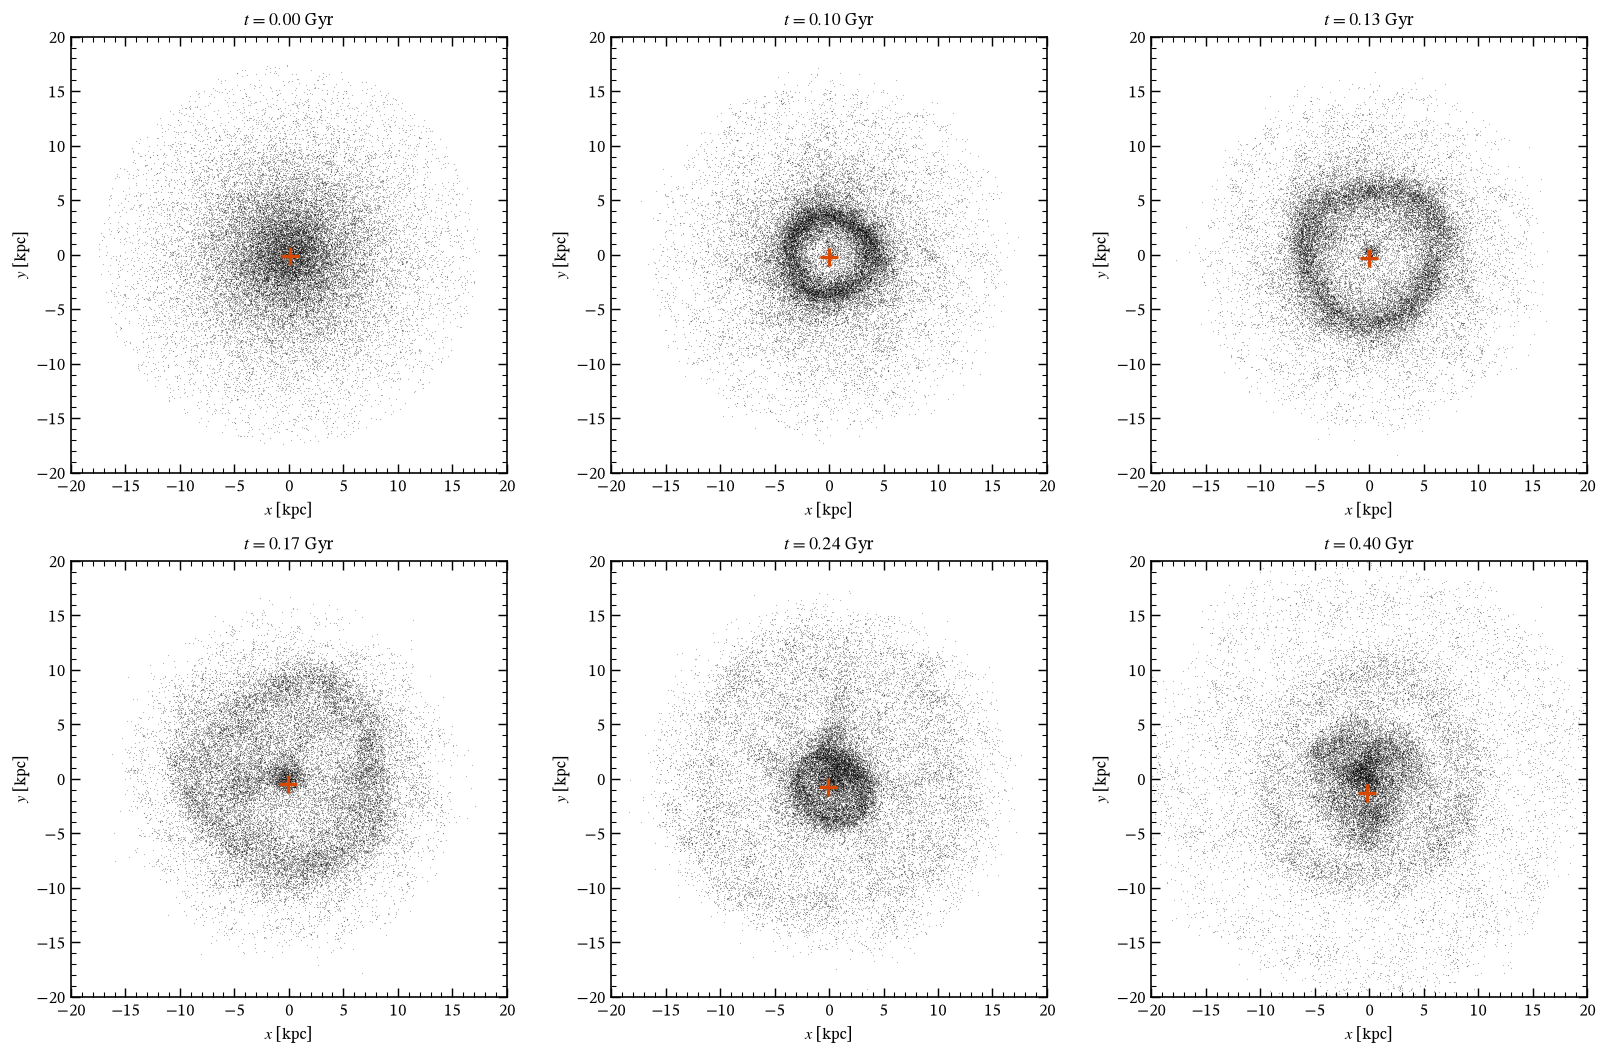

In [10]:
# Times chosen relative to the impact rather than spread evenly over the run:
# the ring is a transient, and sampling it uniformly over 0.8 Gyr would show
# five panels of aftermath and one of ring.
t_show = [0.0] + list(t_cross + np.array([0.02, 0.05, 0.09, 0.16, 0.32]))

fig, axes = plt.subplots(2, 3, figsize=(12.6, 8.2))
for ax, t in zip(axes.ravel(), t_show):
    ax.scatter(sim.disk.x(t=float(t)), sim.disk.y(t=float(t)),
               s=0.45, lw=0, c="k", alpha=0.30)
    # The intruder as one marker at its centre of mass: in projection it sits at
    # the origin whatever its height above the plane.
    ax.plot(sim.intruder.x(t=float(t)).mean(), sim.intruder.y(t=float(t)).mean(),
            "+", c="#d94801", ms=10, mew=1.8)
    ax.set_xlim(-20, 20)
    ax.set_ylim(-20, 20)
    ax.set_aspect("equal")
    ax.set_title(f"$t = {t:.2f}$ Gyr")
    ax.set_xlabel("$x$ [kpc]")
    ax.set_ylabel("$y$ [kpc]")

fig.tight_layout()
plt.show()

## 5. Following the ring quantitatively

Eyeballing a ring is easy; measuring one is the useful skill. Azimuthally
average the disk's surface density in radial annuli at every snapshot, which
turns the two-dimensional picture into a clean $\Sigma(R, t)$ map.

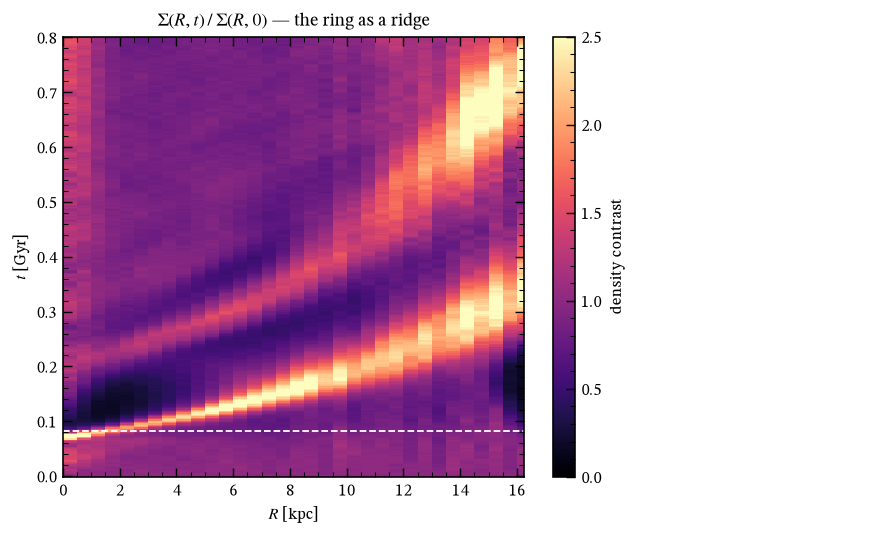

In [11]:
edges = np.linspace(0.0, 30.0, 61)
centres = 0.5 * (edges[1:] + edges[:-1])
area = np.pi * np.diff(edges**2)  # kpc^2

sigma_Rt = []
for i in range(len(sim.times)):
    R = np.hypot(sim.disk.x(t=i), sim.disk.y(t=i))
    counts, _ = np.histogram(R, bins=edges, weights=sim.disk.mass)
    sigma_Rt.append(counts / area)
sigma_Rt = np.array(sigma_Rt)  # (n_snap, n_bins)

# Contrast against the initial profile: the ring is an *enhancement*. Outside the
# disk's initial edge Sigma(R,0) is essentially zero, so the ratio is meaningless
# there -- mask it rather than letting it saturate the colour scale.
valid = sigma_Rt[0] > 0.01 * sigma_Rt[0].max()
contrast = np.full_like(sigma_Rt, np.nan)
contrast[:, valid] = sigma_Rt[:, valid] / sigma_Rt[0][valid]

fig, ax = plt.subplots(figsize=(7.2, 4.2))
im = ax.pcolormesh(centres, sim.times, contrast, cmap="magma",
                   vmin=0.0, vmax=2.5, shading="auto")
ax.set_xlim(0.0, centres[valid].max())
ax.axhline(t_cross, c="w", ls="--", lw=1.0)
ax.text(28.0, t_cross, " impact", color="w", va="bottom", ha="right", fontsize=9)
ax.set_xlabel("$R$ [kpc]")
ax.set_ylabel("$t$ [Gyr]")
ax.set_title(r"$\Sigma(R,t)\,/\,\Sigma(R,0)$ — the ring as a ridge")
fig.colorbar(im, ax=ax, label="density contrast")
fig.tight_layout()
plt.show()

The ridge running up and to the right *is* the ring. Read off its position at
each time by taking the radius of peak contrast, ignoring the crowded centre.

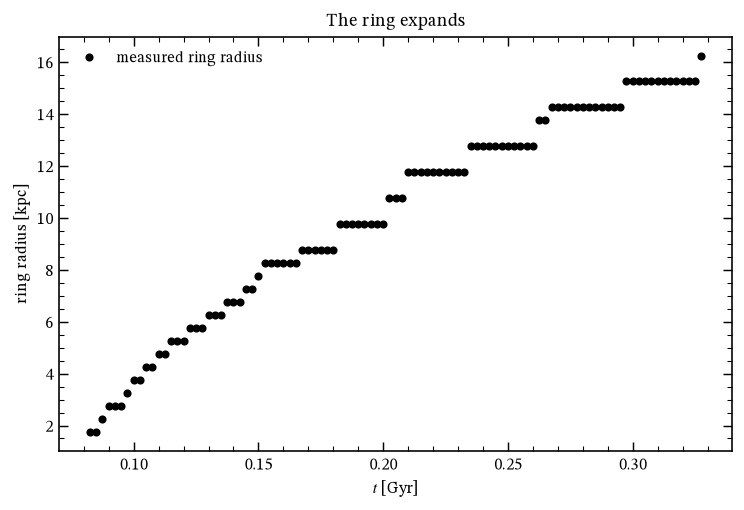

In [12]:
# Taking a global argmax at each snapshot does not work: once the first ring
# reaches the edge of the disk the peak sticks there, and when the *second*
# ring appears the track jumps back inward. Follow one ring instead, searching
# a window around where it was at the previous snapshot.
# Track only where the disk started with real surface density: beyond that the
# disk is expanding into near-vacuum, and Sigma/Sigma_0 is large there for
# reasons that have nothing to do with the ring.
search = valid & (centres > 1.5)
R_track_max = centres[search].max()
ring_R = np.full(len(sim.times), np.nan)
prev = None
for i in range(len(sim.times)):
    if sim.times[i] < t_cross:
        continue
    if prev is None:
        window = search
    else:
        # Between snapshots the ring advances by at most v*dt_out ~ 0.25 kpc at
        # 100 km/s, so the window only needs to be a couple of bins wide. Make
        # it any wider and the track leaps to the disk's expanding outer edge.
        window = search & (centres > prev - 0.5) & (centres < prev + 1.5)
    if not window.any():
        break
    j = int(np.argmax(np.where(window, contrast[i], -np.inf)))
    prev = centres[j]
    ring_R[i] = prev
    # Once the ring reaches the edge of the trackable region, stop rather than
    # reporting a flat line that is really the boundary, not the ring.
    if prev >= R_track_max - 0.6:
        break

tracked = np.isfinite(ring_R)

fig, ax = plt.subplots(figsize=(5.8, 4.0))
ax.plot(sim.times[tracked], ring_R[tracked], "ko", ms=3.5,
        label="measured ring radius")
ax.set_xlabel("$t$ [Gyr]")
ax.set_ylabel("ring radius [kpc]")
ax.set_title("The ring expands")
ax.legend()
fig.tight_layout()
plt.show()

## 6. The ring in motion

The snapshots above are the honest way to *measure* the ring, but the wave is
much easier to believe when you watch it. Three views of the same moment:

- **Face-on** — the ring opening out, with the centre draining behind it.
- **Edge-on** — the companion (orange) dropping in from below, crossing, and
  leaving. Note how little the disk thickens: the response is almost entirely
  radial, which is why a *ring* forms rather than a puffed-up mess.
- **Density contrast** — the same profile as above, as a travelling bump.

70 frames, 2.1 MB


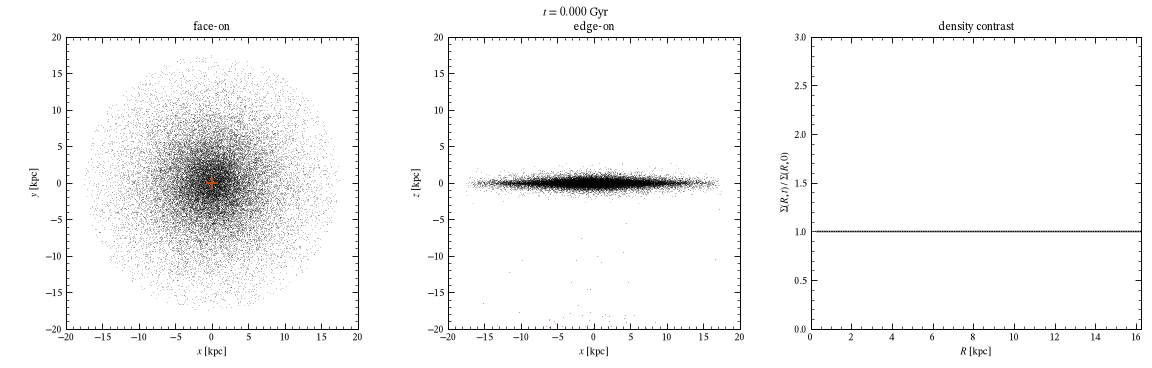

In [13]:
from IPython.display import Image  # noqa: E402
from matplotlib.animation import FuncAnimation, PillowWriter  # noqa: E402

# The ring is a transient, so animate the window it actually lives in rather
# than the whole run.
t_anim = np.linspace(0.0, min(0.55, sim.times[-1]), 70)
idx_anim = np.searchsorted(sim.times, t_anim).clip(0, len(sim.times) - 1)

fig, (axL, axM, axR) = plt.subplots(1, 3, figsize=(14.4, 4.6))

# Face-on.
sc = axL.scatter([], [], s=0.45, lw=0, c="k", alpha=0.30)
(mk,) = axL.plot([], [], "+", c="#d94801", ms=10, mew=1.8)
axL.set_xlim(-20, 20)
axL.set_ylim(-20, 20)
axL.set_aspect("equal")
axL.set_xlabel("$x$ [kpc]")
axL.set_ylabel("$y$ [kpc]")
axL.set_title("face-on")

# Edge-on. The z range is set by the intruder's approach, not the disk: the disk
# is only a few hundred pc thick, so this view is mostly there to show the
# companion arriving, punching through, and leaving.
sc_e = axM.scatter([], [], s=0.45, lw=0, c="k", alpha=0.30)
sc_i = axM.scatter([], [], s=0.8, lw=0, c="#d94801", alpha=0.45)
axM.set_xlim(-20, 20)
axM.set_ylim(-20, 20)
axM.set_aspect("equal")
axM.set_xlabel("$x$ [kpc]")
axM.set_ylabel("$z$ [kpc]")
axM.set_title("edge-on")

# Radial contrast.
(line,) = axR.plot([], [], "k")
axR.axhline(1.0, c="0.7", lw=0.8, ls=":")
axR.set_xlim(0.0, centres[valid].max())
axR.set_ylim(0.0, 3.0)
axR.set_xlabel("$R$ [kpc]")
axR.set_ylabel(r"$\Sigma(R,t)\,/\,\Sigma(R,0)$")
axR.set_title("density contrast")

ttl = fig.suptitle("")
fig.tight_layout()


def update(k):
    i = int(idx_anim[k])
    dx, dy, dz = sim.disk.x(t=i), sim.disk.y(t=i), sim.disk.z(t=i)
    sc.set_offsets(np.c_[dx, dy])
    mk.set_data([sim.intruder.x(t=i).mean()], [sim.intruder.y(t=i).mean()])
    sc_e.set_offsets(np.c_[dx, dz])
    sc_i.set_offsets(np.c_[sim.intruder.x(t=i), sim.intruder.z(t=i)])
    line.set_data(centres[valid], contrast[i][valid])
    ttl.set_text(f"$t = {sim.times[i]:.3f}$ Gyr")
    return sc, mk, sc_e, sc_i, line, ttl


anim = FuncAnimation(fig, update, frames=range(len(idx_anim)), blit=False)
anim.save("ring_galaxy.gif", writer=PillowWriter(fps=12), dpi=80)
plt.close(fig)

# Redrawing a 30 000-point scatter every frame defeats GIF inter-frame
# compression, so quantise the palette afterwards -- same trick as example 05.
from PIL import Image as PILImage, ImageSequence  # noqa: E402

_src = PILImage.open("ring_galaxy.gif")
_fr = [f.copy().convert("RGB").quantize(colors=96, method=PILImage.MEDIANCUT)
       for f in ImageSequence.Iterator(_src)]
_fr[0].save("ring_galaxy.gif", save_all=True, append_images=_fr[1:],
            duration=90, loop=0, optimize=True)
print(f"{len(_fr)} frames, "
      f"{__import__('os').path.getsize('ring_galaxy.gif') / 1e6:.1f} MB")

Image(filename="ring_galaxy.gif")

## 7. Is it really a kinematic wave?

Here is the test that separates the two explanations. If the ring were a
physical shell of material, the same stars would stay in it, and the ring would
move at roughly the speed those stars were kicked to. If it is a kinematic
caustic, the stars should be **passing through** it: individual stars stay on
their own epicycles, and the ring is just where the crowding happens.

So take the particles that make up the ring at a late snapshot, and ask where
they were earlier.

2795 particles in the ring at t = 0.33 Gyr
  their median R then      : 16.02 kpc
  their median R at 0.19 Gyr : 12.04 kpc
  ring radius at 0.19 Gyr    : 9.75 kpc


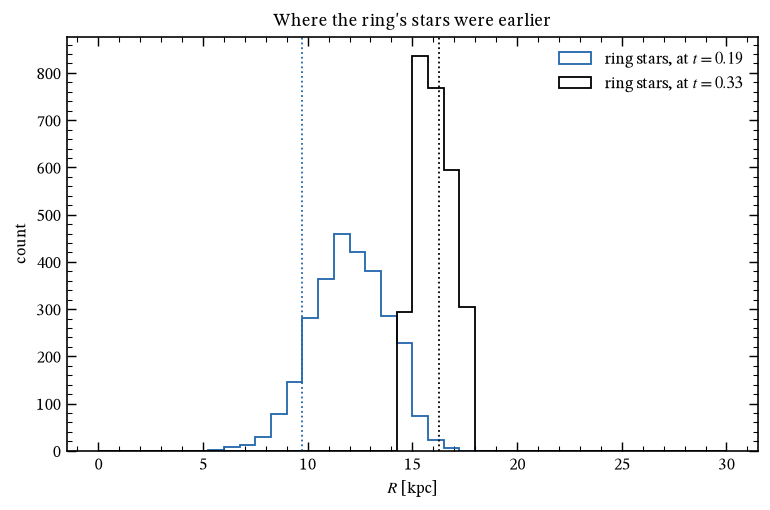

In [14]:
i_late = int(np.max(np.flatnonzero(tracked)))  # last snapshot with a tracked ring
R_late = np.hypot(sim.disk.x(t=i_late), sim.disk.y(t=i_late))
in_ring = np.abs(R_late - ring_R[i_late]) < 1.5

i_mid = int(np.min(np.flatnonzero(tracked)) + 0.45 * (i_late - np.min(np.flatnonzero(tracked))))
R_mid = np.hypot(sim.disk.x(t=i_mid), sim.disk.y(t=i_mid))

print(f"{in_ring.sum()} particles in the ring at t = {sim.times[i_late]:.2f} Gyr")
print(f"  their median R then      : {np.median(R_late[in_ring]):.2f} kpc")
print(f"  their median R at {sim.times[i_mid]:.2f} Gyr : "
      f"{np.median(R_mid[in_ring]):.2f} kpc")
print(f"  ring radius at {sim.times[i_mid]:.2f} Gyr    : {ring_R[i_mid]:.2f} kpc")

fig, ax = plt.subplots(figsize=(6.0, 4.0))
ax.hist(R_mid[in_ring], bins=40, range=(0, 30), histtype="step", color="#2166ac",
        label=f"ring stars, at $t={sim.times[i_mid]:.2f}$")
ax.hist(R_late[in_ring], bins=40, range=(0, 30), histtype="step", color="k",
        label=f"ring stars, at $t={sim.times[i_late]:.2f}$")
ax.axvline(ring_R[i_mid], c="#2166ac", ls=":", lw=1.0)
ax.axvline(ring_R[i_late], c="k", ls=":", lw=1.0)
ax.set_xlabel("$R$ [kpc]")
ax.set_ylabel("count")
ax.set_title("Where the ring's stars were earlier")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

If the stars now in the ring were spread over a wide range of radii earlier —
and in particular were *not* concentrated at the earlier ring radius — then the
ring is not a fixed set of particles. It is a pattern that different stars move
into and out of, which is exactly the Lynds & Toomre picture.

## 8. Caveats worth carrying forward

- **The halo is rigid.** It cannot absorb energy, so there is no dynamical
  friction on the intruder. In reality the companion would decay and eventually
  merge; here it sails away on a straight-ish line. For ring morphology over
  half a gigayear this hardly matters, but do not use this setup to ask about
  the companion's fate.
- **The disk is collisionless but under-resolved.** 30 000 particles is enough
  for the ring, not for the spiral structure or the gas physics that makes the
  Cartwheel's ring so spectacular in the real universe. There is no gas here at
  all, and it is the gas that forms the star-forming knots.
- **The IC is an approximate equilibrium.** The epicyclic approximation is a
  first-order treatment, so the disk settles a little in the first ~100 Myr
  independently of the collision. Compare against a control run with no
  intruder before attributing any feature to the encounter.

## Summary

- A disk is a hand-rolled IC: sample $\rho(R,z)$, then set velocities from
  $v_c$, the Toomre $Q$, and asymmetric drift.
- An expensive galpy potential should be evaluated on a grid and interpolated,
  never per particle.
- `add_external_pot` for the rigid halo, live components for the disk and the
  intruder, and a per-component `eps` dict because their densities differ.
- The ring is a kinematic caustic. The test is to check whether the same stars
  stay in it — they do not.